In [1]:
# importing the file

In [2]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy.io import fits
import matplotlib.pyplot as plt

In [3]:
image = '../images/hlsp_ceers_jwst_nircam_nircam8_f444w_dr0.6_i2d.fits'
file = fits.open(image)

In [4]:
# image structure

In [5]:
file.info()

Filename: ../images/hlsp_ceers_jwst_nircam_nircam8_f444w_dr0.6_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     375   ()      
  1  SCI_BKSUB     1 ImageHDU        75   (11500, 6500)   float64   
  2  SCI           1 ImageHDU        75   (11500, 6500)   float32   
  3  ERR           1 ImageHDU        10   (11500, 6500)   float32   
  4  CON           1 ImageHDU        10   (11500, 6500, 1)   int32   
  5  WHT           1 ImageHDU         9   (11500, 6500)   float32   
  6  VAR_POISSON    1 ImageHDU         9   (11500, 6500)   float32   
  7  VAR_RNOISE    1 ImageHDU         9   (11500, 6500)   float32   
  8  VAR_FLAT      1 ImageHDU         9   (11500, 6500)   float32   
  9  BKGD          1 ImageHDU        39   (11500, 6500)   float64   
 10  BKGMASK       1 ImageHDU        41   (11500, 6500)   uint8 (rescales to int8)   
 11  HDRTAB        1 BinTableHDU    820   6R x 405C   [23A, 5A, 3A, 51A, 7A, 13A, 3A, 5A, 7A, 10A, 4A, L, 

In [6]:
sci = file["SCI"].data
err = file["ERR"].data
sci_bkgsub = file["SCI_BKSUB"].data
wht = file["WHT"].data
nodata = (wht <= 0) | (sci == 0) | ~np.isfinite(sci)
print(nodata.mean())

0.5013263010033445


In [7]:
sci

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6500, 11500), dtype='>f4')

In [8]:
err

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(6500, 11500), dtype='>f4')

In [9]:
# finding the global sky threshold and noise spread

In [10]:
h, w = sci.shape
tile = 200
n_rows, n_cols = h // tile, w // tile
medians = np.full((n_rows, n_cols), np.nan)
spreads = np.full((n_rows, n_cols), np.nan)

for i in range(n_rows):
    for j in range(n_cols):
        box      = sci[i*tile:(i+1)*tile, j*tile:(j+1)*tile]
        box_mask = nodata[i*tile:(i+1)*tile, j*tile:(j+1)*tile]
        real = box[~box_mask]
        if real.size < 0.5 * box.size:
            continue
        mean, med, stddev = sigma_clipped_stats(real)
        medians[i, j] = med
        spreads[i, j] = stddev

In [11]:
sky   = np.nanmedian(medians)
noise = np.nanmedian(spreads)
rms   = np.sqrt(np.nanmedian(spreads**2))
n = 5
threshold = sky + n * noise
suspects = (sci > threshold) & ~nodata
print(suspects.mean())

0.011583505016722407


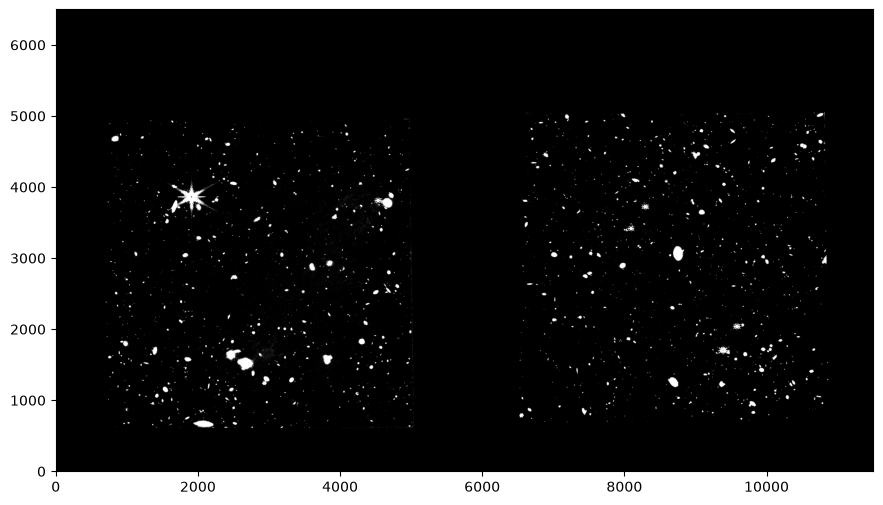

In [12]:
plt.figure(figsize=(12, 6))
plt.imshow(suspects, origin="lower", cmap="grey")
plt.show()

In [13]:
# source detection & labeling on a 2000px * 2000px testing tile

In [14]:
y0, y1, x0, x1 = 3000, 5000, 1000, 3000
cut      = sci[y0:y1, x0:x1].astype(np.float64)
cut_mask = nodata[y0:y1, x0:x1]
print(cut_mask.mean())

0.032179


In [15]:
from photutils.segmentation import detect_sources

cut_sub = cut - sky
segm = detect_sources(cut_sub, threshold=n * noise, n_pixels=5, mask=cut_mask)
print(segm.n_labels)

500


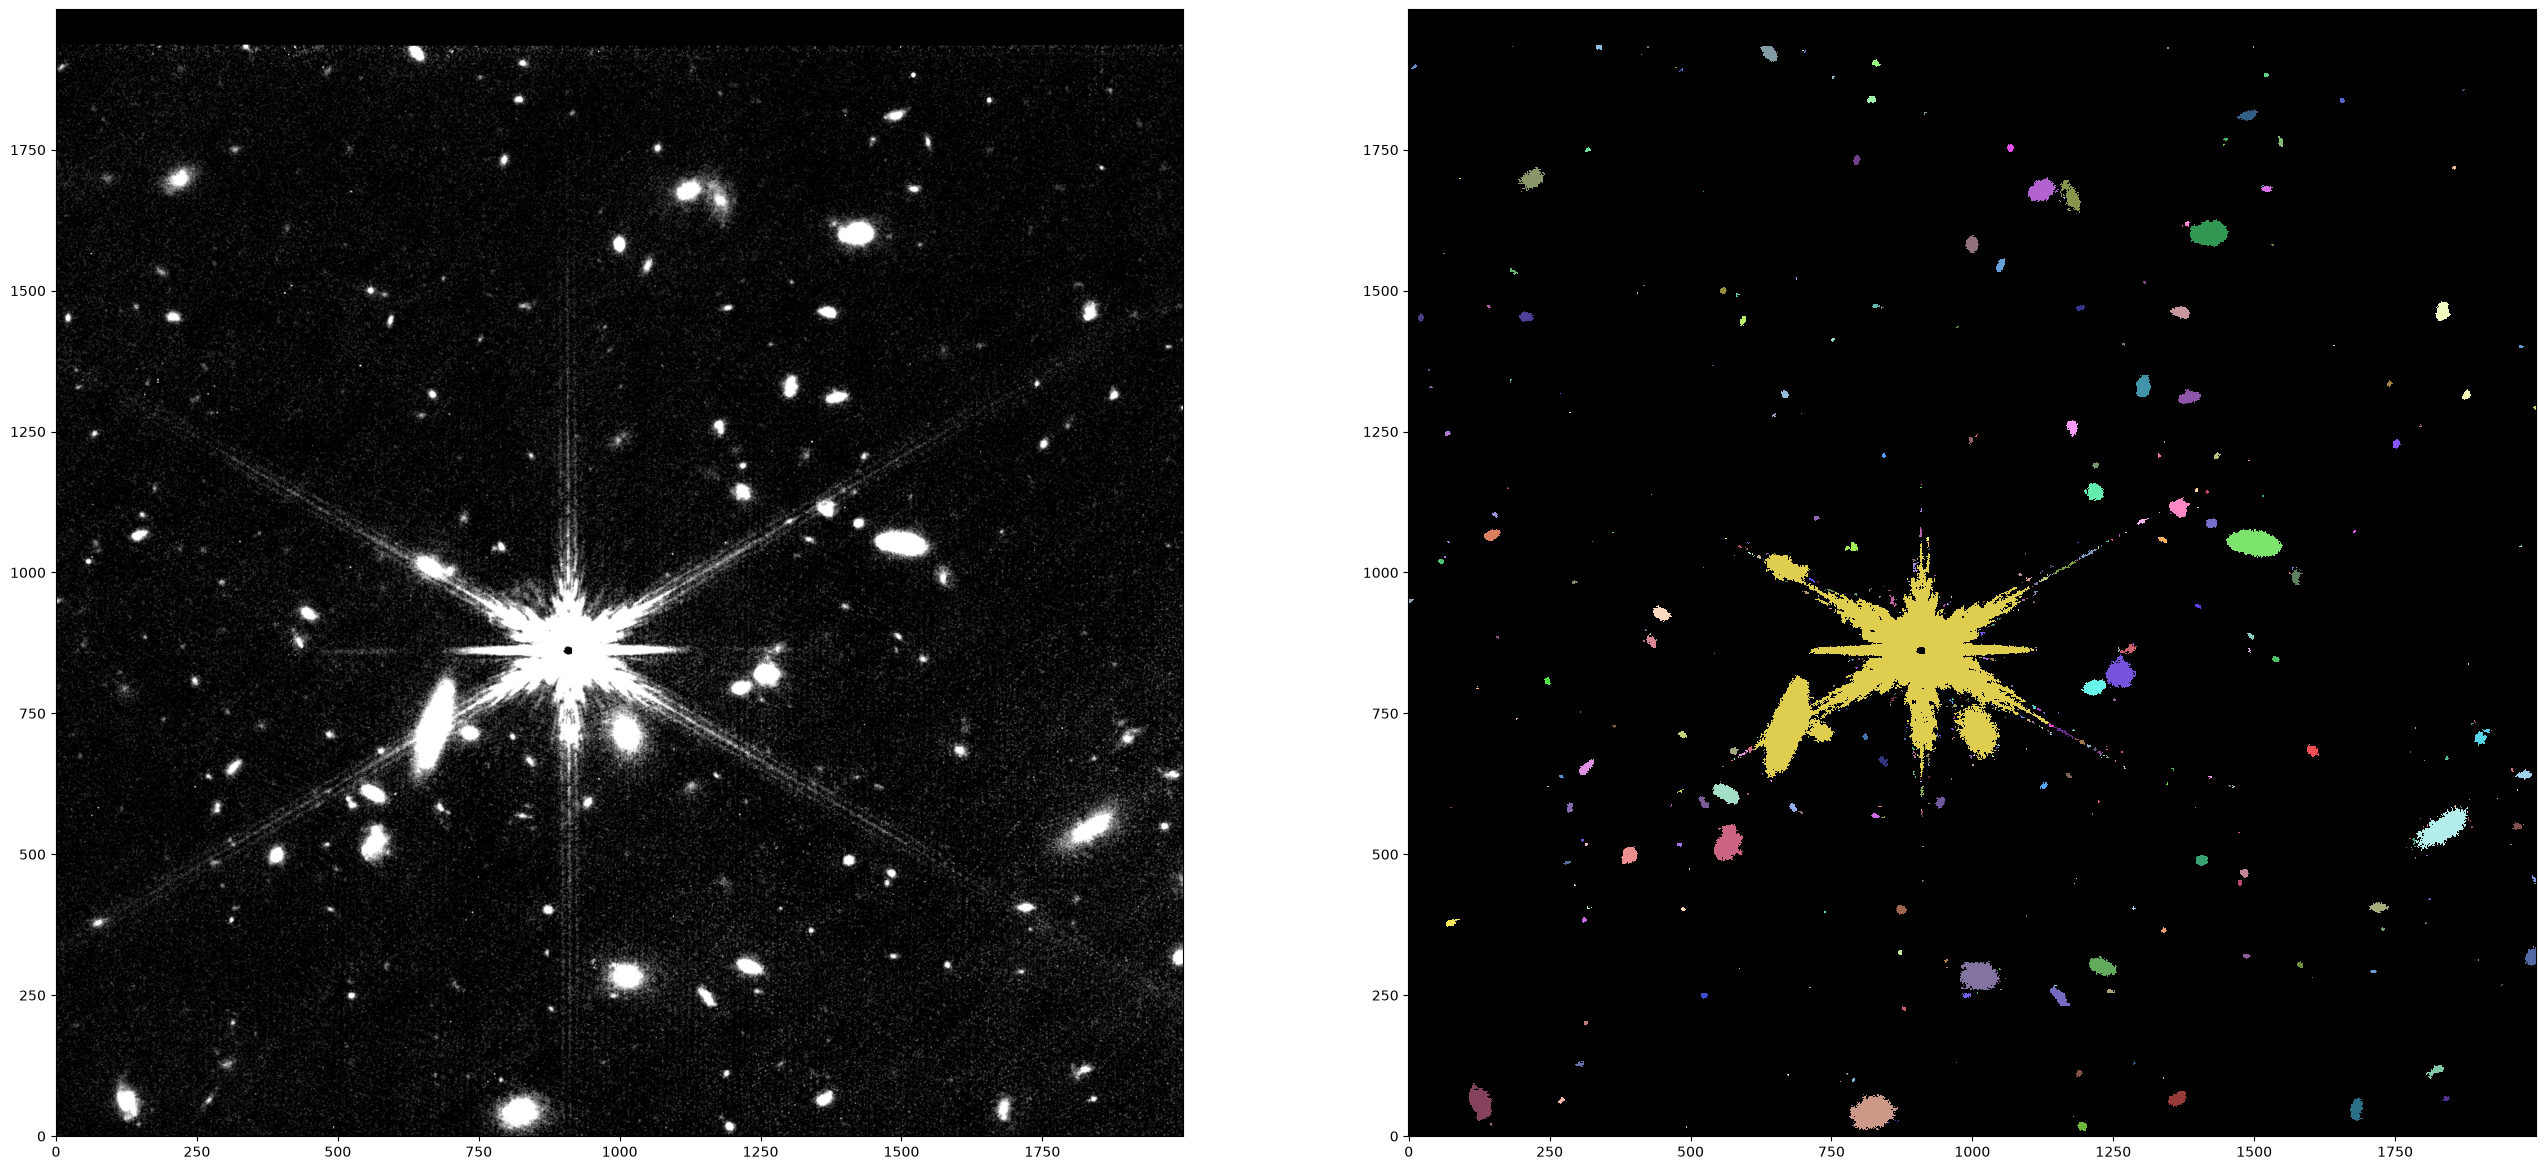

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(32, 16))
ax[0].imshow(cut_sub, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm.data, origin="lower", cmap=segm.cmap, interpolation="nearest")
plt.show()

In [17]:
# instead of a single global threshold, we can divide the tile in hundred sub-tiles and define their sky threshold separately

In [18]:
from scipy.ndimage import zoom

spreads_cut = spreads[15:25, 5:15]
spreads_cut = np.where(np.isnan(spreads_cut), rms, spreads_cut)
rms_cut = zoom(spreads_cut, 200, order=1, grid_mode=True, mode="nearest")

medians_cut = medians[15:25, 5:15]
medians_cut = np.where(np.isnan(medians_cut), sky, medians_cut)
sky_cut = zoom(medians_cut, 200, order=1, grid_mode=True, mode="nearest")
cut_sub = cut - sky_cut # sky subtracted image with better sky threshold definintion, using the "zoom" method 
print(rms_cut.shape)

(2000, 2000)


In [19]:
segm_local = detect_sources(cut_sub, threshold=n * rms_cut, n_pixels=5, mask=cut_mask)
print(segm_local.n_labels)

252


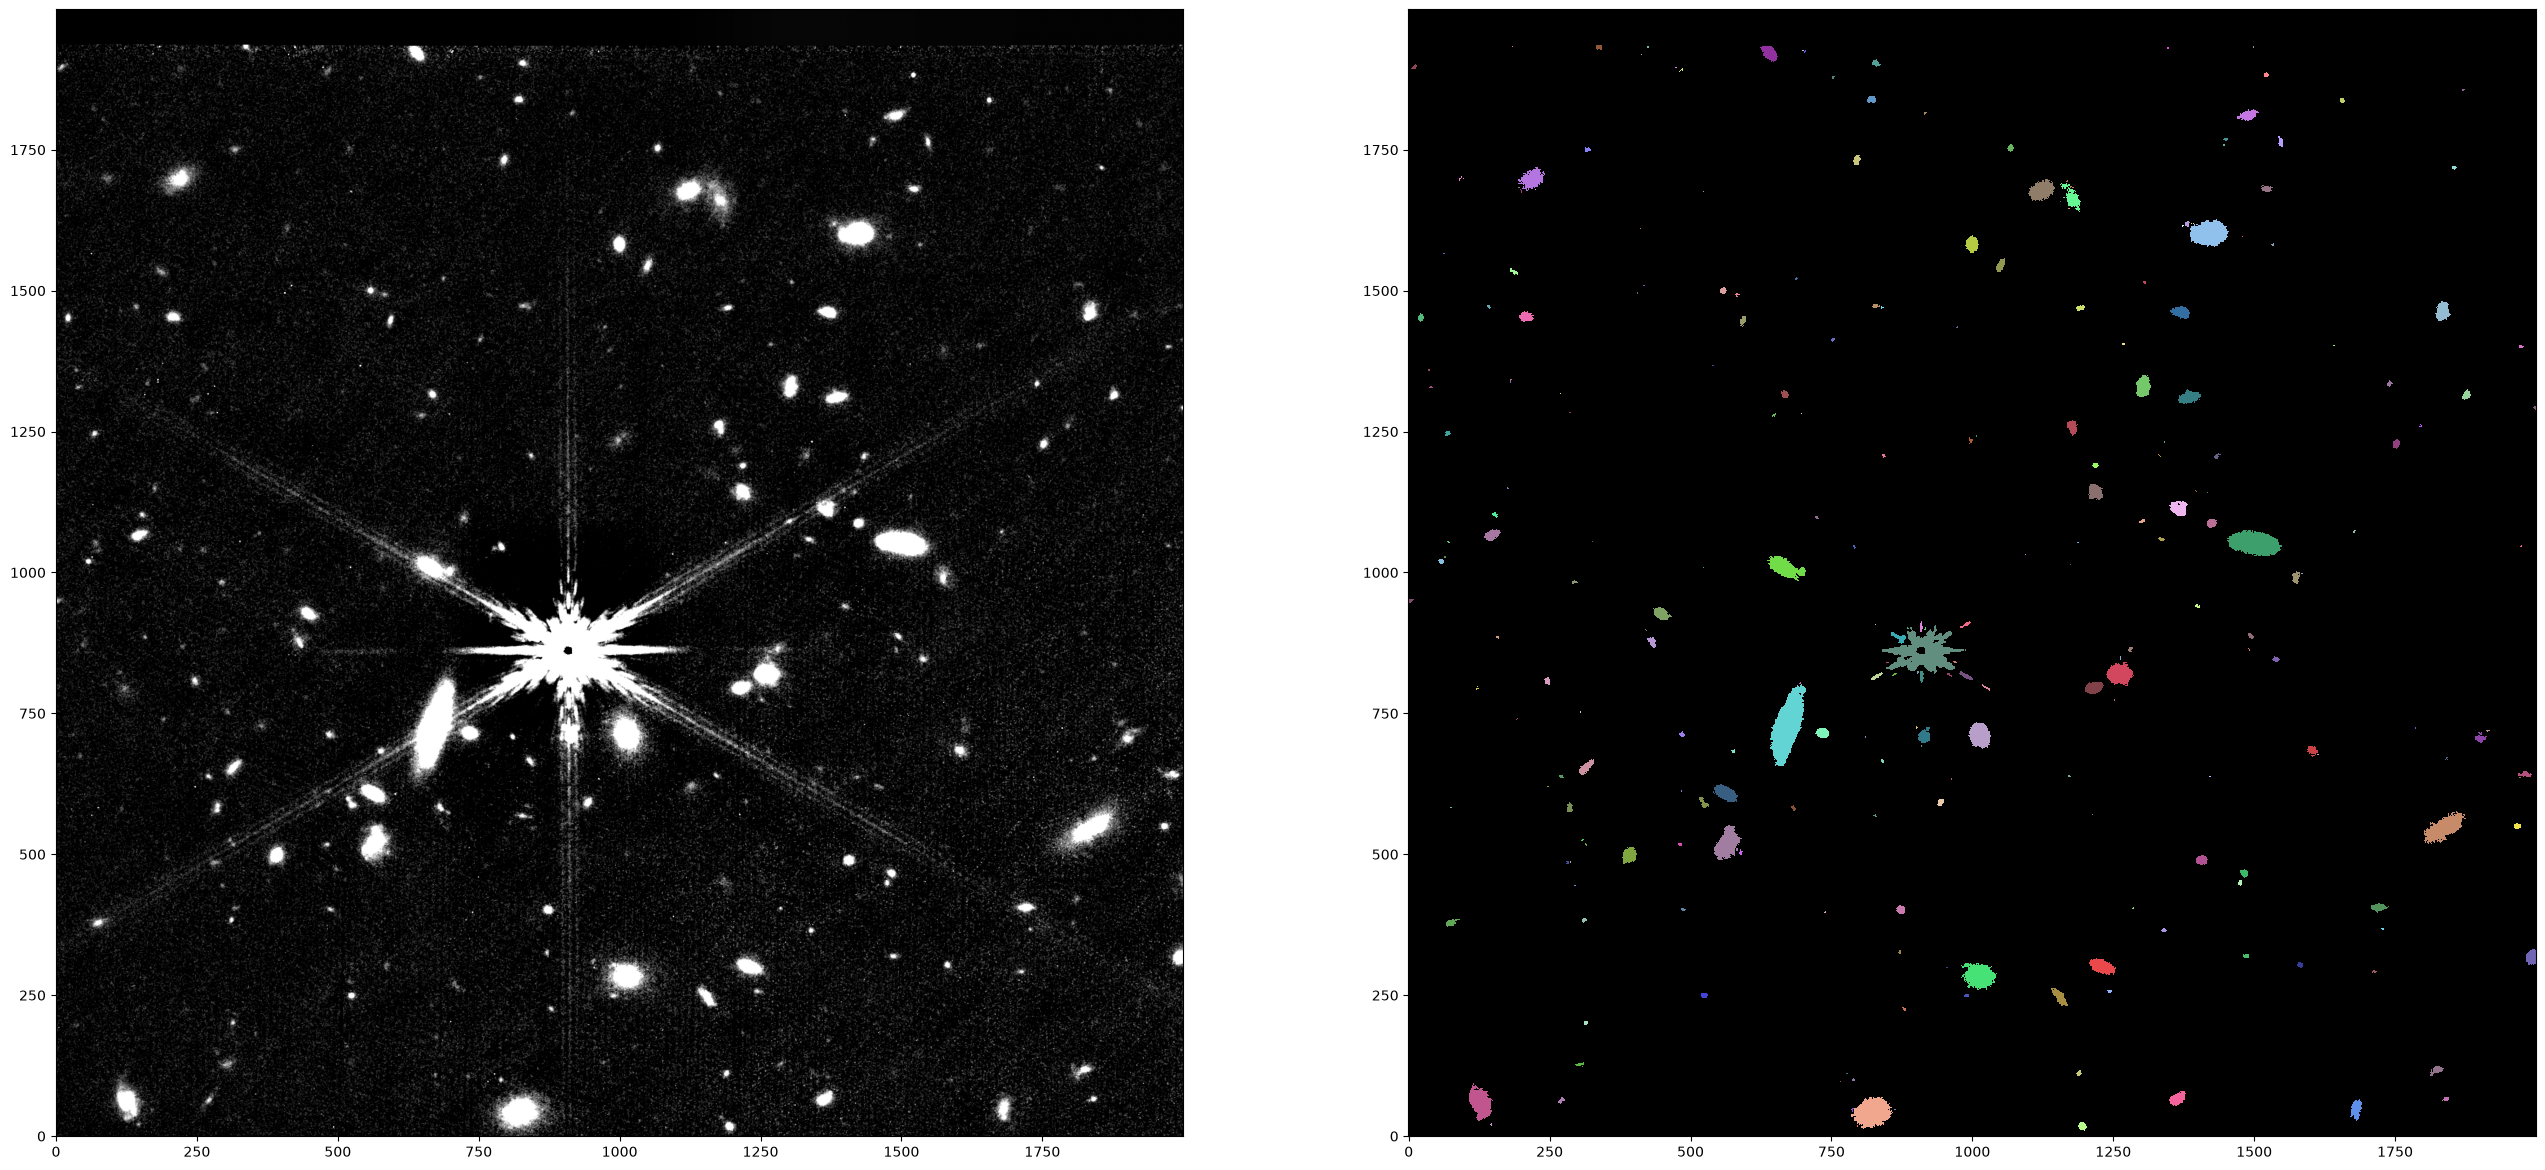

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(32, 16))
ax[0].imshow(cut_sub, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm_local.data, origin="lower", cmap=segm_local.cmap, interpolation="nearest")
plt.show()

In [21]:
# convolving to not lose the edge pixels of the source and avoid them counted as a different source. 

In [22]:
# consequently this step will cause a drop in count of the detected sources. 

In [23]:
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel

kernel = make_2dgaussian_kernel(5.0, size=11)
conv = convolve(cut_sub, kernel, mask=cut_mask)
segm_conv = detect_sources(conv, threshold=n * rms_cut, n_pixels=5, mask=cut_mask)
print(segm_conv.n_labels)

133


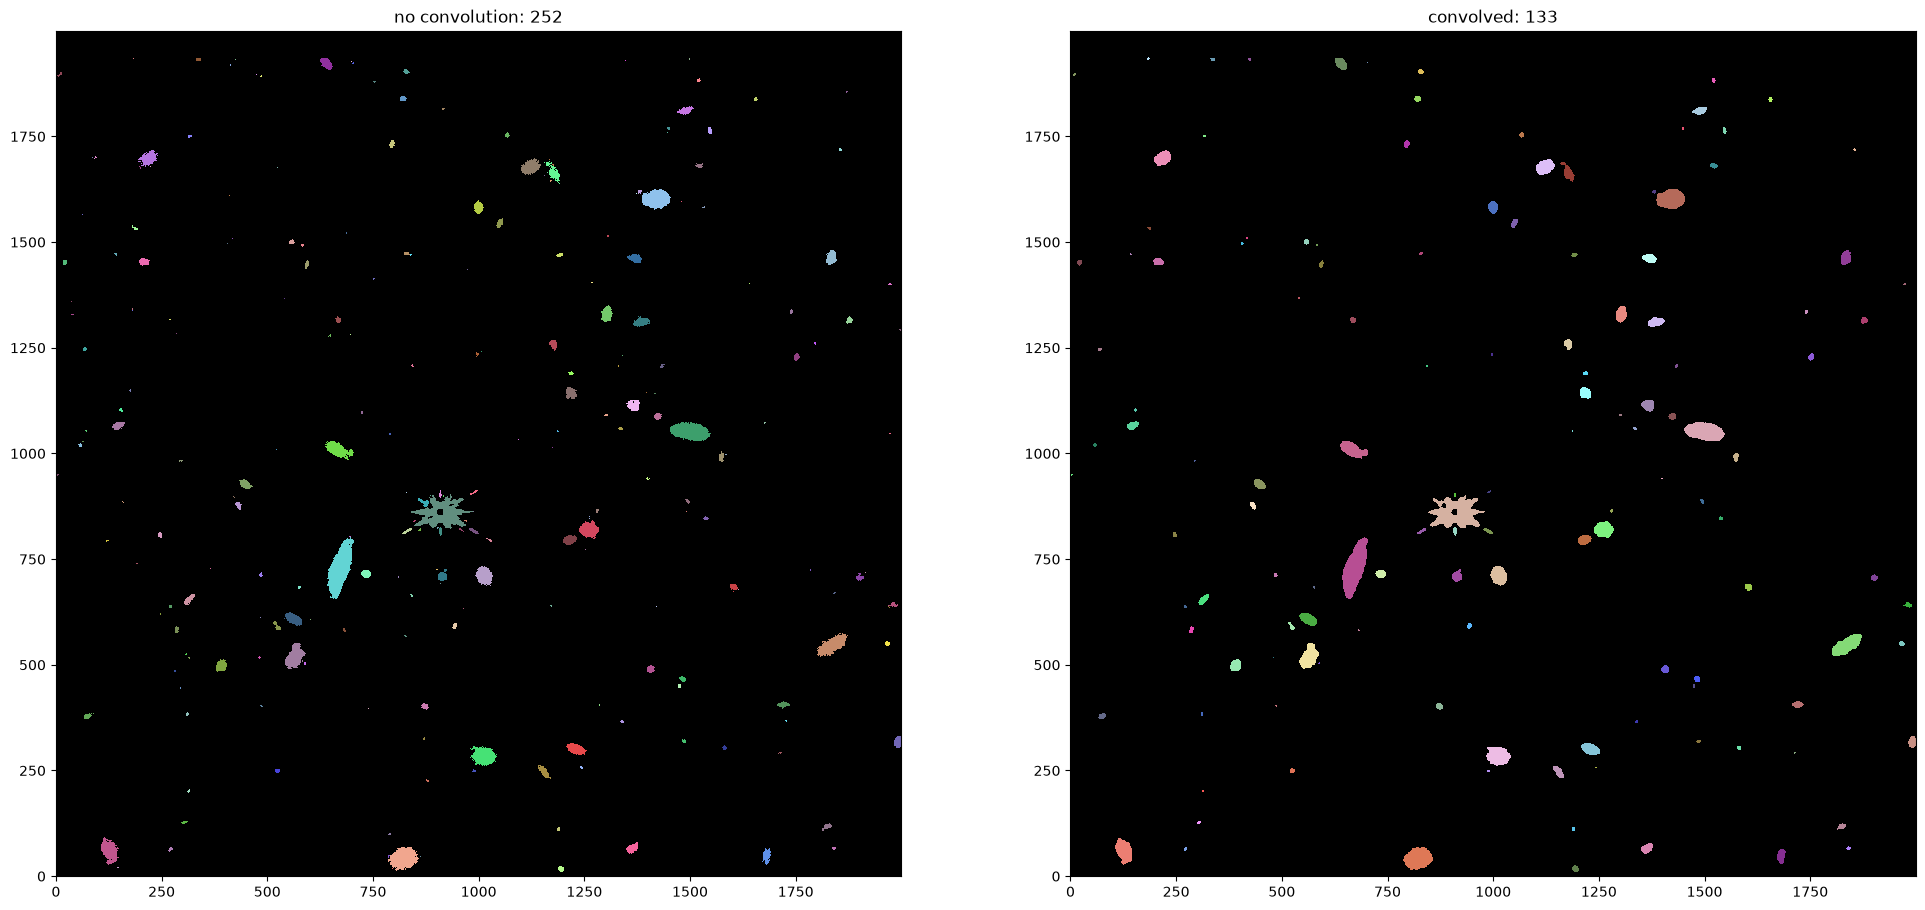

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(segm_local.data, origin="lower", cmap=segm_local.cmap, interpolation="nearest")
ax[0].set_title(f"no convolution: {segm_local.n_labels}")
ax[1].imshow(segm_conv.data, origin="lower", cmap=segm_conv.cmap, interpolation="nearest")
ax[1].set_title(f"convolved: {segm_conv.n_labels}")
plt.show()

In [25]:
# let's assign each detected source a unique, global coorindation using the WCS method. 

In [26]:
from astropy.wcs import WCS
wcs_full = WCS(file["SCI"].header)
wcs_cut  = wcs_full[y0:y1, x0:x1]

Set DATE-AVG to '2022-12-21T22:35:56.215' from MJD-AVG.
Set DATE-END to '2022-12-21T23:02:59.197' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.966384 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677828190.312 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [27]:
# doing some math to better understand the constraints of the captured image. 

In [28]:
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

pixscale = (proj_plane_pixel_scales(wcs_cut)[0] * u.deg).to(u.arcsec).value
psf_fwhm_arcsec = (4.44e-6 / 6.5) * 206265
psf_fwhm_pix    = psf_fwhm_arcsec / pixscale
psf_sigma_pix   = psf_fwhm_pix / 2.355
psf_area_pix    = np.pi * (psf_fwhm_pix / 2)**2
print(f"{pixscale:.4f} arcsec/pix | FWHM {psf_fwhm_pix:.2f} pix | sigma {psf_sigma_pix:.2f} pix | PSF area {psf_area_pix:.1f} pix^2")

0.0300 arcsec/pix | FWHM 4.70 pix | sigma 1.99 pix | PSF area 17.3 pix^2


In [29]:
ksize = int(2 * np.ceil(2 * psf_fwhm_pix) + 1)
kernel = make_2dgaussian_kernel(psf_fwhm_pix, size=ksize)
conv = convolve(cut_sub, kernel, mask=cut_mask)
MIN_NPIX = int(np.ceil(0.5 * psf_area_pix))
segm_conv = detect_sources(conv, threshold=n * rms_cut, n_pixels=MIN_NPIX, mask=cut_mask)

In [30]:
# deblending the sources

In [31]:
from photutils.segmentation import deblend_sources
segm_deblend = deblend_sources(conv, segm_conv, n_pixels=MIN_NPIX, n_levels=32, contrast=0.001, progress_bar=False)
print(f"kernel {psf_fwhm_pix:.2f} px, n_pixels {MIN_NPIX} -> {segm_conv.n_labels} detected, {segm_deblend.n_labels} after deblend")

kernel 4.70 px, n_pixels 9 -> 132 detected, 150 after deblend


In [32]:
# grouping the siblings together. (a source comes with it's siblings, and each .fits file includes separate headers, each standing for a sibling)

In [33]:
from collections import defaultdict

parent_of = {}
for lab, sl in zip(segm_deblend.labels, segm_deblend.slices):
    child = segm_deblend.data[sl] == lab
    parents = segm_conv.data[sl][child]
    parents = parents[parents > 0]
    if parents.size == 0:
        parent_of[int(lab)] = int(lab)
    else:
        parent_of[int(lab)] = int(np.bincount(parents).argmax())

children_of = defaultdict(list)
for lab, p in parent_of.items():
    children_of[p].append(lab)

for lab in segm_conv.labels:
    if lab not in children_of:
        children_of[lab] = [lab]
        parent_of[lab] = lab

shreds = {p: ch for p, ch in children_of.items() if len(ch) > 1}
print(f"{segm_conv.n_labels} parents -> {segm_deblend.n_labels} children")
print(f"{len(shreds)} parents split, producing {sum(len(ch) for ch in shreds.values())} children")

132 parents -> 150 children
11 parents split, producing 29 children


In [34]:
err_cut = err[y0:y1, x0:x1].astype(np.float64)

from photutils.segmentation import SourceCatalog
cat = SourceCatalog(data=cut_sub, segmentation_image=segm_deblend, convolved_data=conv, error=err_cut, mask=cut_mask, wcs=wcs_cut)
tbl = cat.to_table(columns=["label", "x_centroid", "y_centroid", "sky_centroid", "bbox_xmin", "bbox_xmax", "bbox_ymin", "bbox_ymax", "area", "segment_flux", "segment_flux_err", "semimajor_axis", "semiminor_axis", "eccentricity", "orientation", "max_value"])
cat_true = SourceCatalog(data=cut_sub, segmentation_image=segm_deblend, error=err_cut, mask=cut_mask, wcs=wcs_cut)
tbl["semimajor_axis"] = cat_true.semimajor_axis
tbl["semiminor_axis"] = cat_true.semiminor_axis
tbl["eccentricity"] = cat_true.eccentricity
tbl["orientation"] = cat_true.orientation
tbl["max_value"] = cat_true.max_value
print(f"Catalog created with {len(tbl)} entries")

Catalog created with 150 entries


In [35]:
flux = tbl["segment_flux"].value
ferr = tbl["segment_flux_err"].value
snr = np.divide(flux, ferr, out=np.full_like(flux, np.nan), where=(ferr > 0))
tbl["snr"] = snr
print(f"SNR range: {np.nanmin(snr):.1f} to {np.nanmax(snr):.1f}")

SNR range: 0.0 to 2914.3


In [36]:
from scipy.ndimage import binary_dilation

def blend_metrics(segm, pad=3):
    d = segm.data
    bf, cf = {}, {}
    for lab in segm.labels:
        sl = segm.slices[segm.get_index(lab)]
        y0 = max(sl[0].start - pad, 0); y1 = min(sl[0].stop + pad, d.shape[0])
        x0 = max(sl[1].start - pad, 0); x1 = min(sl[1].stop + pad, d.shape[1])
        sub = d[y0:y1, x0:x1]
        own = sub == lab
        other = (sub != 0) & ~own
        boundary = binary_dilation(own) & ~own
        bf[int(lab)] = other.sum() / max(own.sum(), 1)
        cf[int(lab)] = (boundary & other).sum() / max(boundary.sum(), 1)
    return bf, cf

_bf, _cf = blend_metrics(segm_deblend)
tbl["blend_frac"] = [_bf[int(l)] for l in tbl["label"]]
tbl["contact_frac"] = [_cf[int(l)] for l in tbl["label"]]
tbl["warn_blended"] = np.asarray(tbl["contact_frac"]) > 0.10

In [37]:
# quality validation filter

In [38]:
# filters (logic to drop a source): 

# 1. negative flux sources (flag_badflux)
# 2. semi-minor axis of the ellipse < MIN_SEMIMINOR || ellipse eccentricity > maximum eccentricity (np.mean(ecc) + std(ecc)) (flag_unresolved)
# 3. area < ~ 17.3 pix^2 (psf_area_pix) (flag_small)
# 4. small signal to noise ratio (SNR) < MIN_SNR (flag_lowsnr)
# 5. source too close to image edge (bbox within EDGE_BUFFER pixels of border) (flag_edge)
# 6. too many bad pixels in source footprint (badfrac > MAX_BADFRAC = 0.05) (flag_baddata)
# 7. mismatch between area and SNR normalized values (|area_norm - snr_norm| > 3.0) (flag_snr_area_mismatch)

In [39]:
tbl["parent_label"] = [parent_of[int(l)] for l in tbl["label"]]
tbl["n_siblings"] = [len(children_of[parent_of[int(l)]]) - 1 for l in tbl["label"]]
tbl["is_deblended_child"] = np.asarray(tbl["n_siblings"]) > 0
tbl["warn_shredded"] = np.asarray(tbl["is_deblended_child"])

area_coefficient = 20
MIN_SEMIMINOR = 0.8 * psf_sigma_pix
MIN_AREA      = area_coefficient * psf_area_pix
MIN_SNR       = 10.0
EDGE_BUFFER   = 10
MAX_BADFRAC   = 0.05
ecc = tbl["eccentricity"].value
μ = np.mean(ecc)
σ = np.std(ecc)
ecc_min = μ - σ
ecc_max = μ + σ

area_vals = tbl["area"].value
area_normalized = (area_vals - np.median(area_vals)) / np.std(area_vals)
snr_normalized = (snr - np.median(snr)) / np.std(snr)
snr_area_mismatch = np.abs(area_normalized - snr_normalized) > 3.0

ny, nx = cut_sub.shape
tbl["badfrac"] = np.array([cut_mask[sl][segm_deblend.data[sl] == lab].mean() for lab, sl in zip(segm_deblend.labels, segm_deblend.slices)])

tbl["flag_badflux"] = ~np.isfinite(snr) | (flux <= 0)
tbl["flag_unresolved"] = (tbl["semiminor_axis"].value < MIN_SEMIMINOR) | (ecc > ecc_max)
tbl["flag_small"] = tbl["area"].value < MIN_AREA
tbl["flag_lowsnr"] = np.nan_to_num(snr, nan=-1) < MIN_SNR
tbl["flag_edge"] = ((tbl["bbox_xmin"] < EDGE_BUFFER) | (tbl["bbox_ymin"] < EDGE_BUFFER) | (tbl["bbox_xmax"] > nx - EDGE_BUFFER) | (tbl["bbox_ymax"] > ny - EDGE_BUFFER))
tbl["flag_baddata"] = tbl["badfrac"] > MAX_BADFRAC
tbl["doubted"] = tbl["eccentricity"].value < ecc_min
tbl["flag_snr_area_mismatch"] = snr_area_mismatch

flagcols = ["flag_badflux", "flag_unresolved", "flag_small", "flag_lowsnr", "flag_edge", "flag_baddata", "flag_snr_area_mismatch"]
tbl["keep"] = ~np.any(np.stack([np.asarray(tbl[c]) for c in flagcols]), axis=0)
print(f"KEEP: {np.asarray(tbl['keep']).sum()} of {len(tbl)}")

KEEP: 30 of 150


In [40]:
tbl_keep = tbl[np.asarray(tbl["keep"])]
print(f"Kept sources: {len(tbl_keep)}")

Kept sources: 30


In [41]:
# 1. stars are point sources well described by PSF

In [42]:
# ============================================
# CLASSIFY PHYSICAL SOURCES (siblings merged)
# ============================================

from astropy.modeling.fitting import LevMarLSQFitter
from astropy.modeling.models import Gaussian2D
from photutils.segmentation import SegmentationImage

# Create physical segmentation (siblings share parent label)
segm_physical_data = np.array(segm_deblend.data)
for lab in segm_deblend.labels:
    p = parent_of[int(lab)]
    if p != lab:
        segm_physical_data[segm_physical_data == lab] = p
segm_physical = SegmentationImage(segm_physical_data)

fitter = LevMarLSQFitter()
sigma_psf = psf_fwhm_pix / 2.355

# Get kept physical labels
kept_physical_labels = set()
for lab in tbl_keep["label"]:
    kept_physical_labels.add(parent_of[int(lab)])

physical_results = []
for label in kept_physical_labels:
    siblings = children_of.get(int(label), [int(label)])
    
    # Find combined bounding box
    sibling_slices = []
    for sib in siblings:
        if sib in segm_deblend.labels:
            sl = segm_deblend.slices[segm_deblend.get_index(sib)]
            sibling_slices.append(sl)
    if not sibling_slices:
        continue
    
    pad = 5
    y_min = max(0, min(sl[0].start for sl in sibling_slices) - pad)
    y_max = min(cut_sub.shape[0], max(sl[0].stop for sl in sibling_slices) + pad)
    x_min = max(0, min(sl[1].start for sl in sibling_slices) - pad)
    x_max = min(cut_sub.shape[1], max(sl[1].stop for sl in sibling_slices) + pad)
    y_slice = slice(y_min, y_max)
    x_slice = slice(x_min, x_max)
    
    source_data = cut_sub[y_slice, x_slice].copy()
    source_err_data = err_cut[y_slice, x_slice].copy()
    
    physical_mask = np.zeros_like(source_data, dtype=bool)
    for sib in siblings:
        physical_mask |= (segm_deblend.data[y_slice, x_slice] == sib)
    
    other_sources = (segm_deblend.data[y_slice, x_slice] != 0) & ~physical_mask
    source_data[other_sources] = np.nan
    
    ny, nx = source_data.shape
    y, x = np.mgrid[:ny, :nx]
    
    initial_amplitude = np.nanmax(source_data)
    if not np.isfinite(initial_amplitude) or initial_amplitude <= 0:
        continue
    
    y_indices, x_indices = np.where(physical_mask)
    if len(x_indices) == 0:
        continue
    
    initial_x = np.mean(x_indices)
    initial_y = np.mean(y_indices)
    
    psf_model = Gaussian2D(amplitude=initial_amplitude, x_mean=initial_x, y_mean=initial_y, x_stddev=sigma_psf, y_stddev=sigma_psf, theta=0.0)
    psf_model.x_stddev.fixed = True
    psf_model.y_stddev.fixed = True
    
    try:
        fitted_model = fitter(psf_model, x, y, source_data, filter_non_finite=True)
        model_values = fitted_model(x, y)
        residuals = source_data - model_values
        
        error_map = source_err_data.copy()
        error_map[other_sources] = np.nan
        error_map[error_map == 0] = np.nan
        
        weighted_residuals = residuals / error_map
        chi2 = np.nansum(weighted_residuals**2)
        n_pixels = np.sum(~np.isnan(source_data))
        dof = n_pixels - 3
        if dof <= 0:
            continue
        chi2_reduced = chi2 / dof
        
        if np.isfinite(chi2_reduced):
            physical_results.append({
                'label': int(label),
                'siblings': siblings,
                'n_siblings': len(siblings),
                'chi2_reduced': chi2_reduced,
                'is_star': chi2_reduced < 3.0,
                'is_galaxy': chi2_reduced >= 3.0
            })
    except:
        continue

# Create classification map
classification = {}
for result in physical_results:
    for sibling in result['siblings']:
        classification[sibling] = {
            'physical_label': result['label'],
            'is_star': result['is_star'],
            'is_galaxy': result['is_galaxy'],
            'n_siblings': result['n_siblings'],
            'chi2_reduced': result['chi2_reduced']
        }

tbl_keep['is_star'] = [classification.get(int(l), {}).get('is_star', False) for l in tbl_keep['label']]
tbl_keep['is_galaxy'] = [classification.get(int(l), {}).get('is_galaxy', False) for l in tbl_keep['label']]
tbl_keep['physical_label'] = [classification.get(int(l), {}).get('physical_label', int(l)) for l in tbl_keep['label']]

print(f"Physical sources: {len(physical_results)}")
print(f"Stars: {sum(1 for r in physical_results if r['is_star'])}")
print(f"Galaxies: {sum(1 for r in physical_results if r['is_galaxy'])}")

Physical sources: 28
Stars: 0
Galaxies: 28


In [43]:
# final notes: 
# 1. those small sources (below the 'MIN_AREA' threshold are not useful anymore and we don't try to bring them back)
# 2. we're going to investigate the isolated galaxies hence, the shreded galaxies (any galaxy with a sibling) is also dropped

In [44]:
# ============================================
# EXPORT GALAXY CUTOUTS
# ============================================

import os

def write_physical_source_cutout(physical_label, siblings, classification_info):
    sibling_slices = []
    for sib in siblings:
        if sib in segm_deblend.labels:
            sl = segm_deblend.slices[segm_deblend.get_index(sib)]
            sibling_slices.append(sl)
    if not sibling_slices:
        return None
    
    pad = 10
    y_min = max(0, min(sl[0].start for sl in sibling_slices) - pad)
    y_max = min(cut_sub.shape[0], max(sl[0].stop for sl in sibling_slices) + pad)
    x_min = max(0, min(sl[1].start for sl in sibling_slices) - pad)
    x_max = min(cut_sub.shape[1], max(sl[1].stop for sl in sibling_slices) + pad)
    y_slice = slice(y_min, y_max)
    x_slice = slice(x_min, x_max)
    
    sci_data = cut_sub[y_slice, x_slice].copy()
    err_data = err_cut[y_slice, x_slice].copy()
    seg_deblend_cut = segm_deblend.data[y_slice, x_slice].copy()
    
    sibling_masks = {}
    for i, sib in enumerate(siblings, 1):
        sibling_masks[f'SIB{i:02d}'] = (seg_deblend_cut == sib).astype(np.uint8)
    
    combined_mask = np.zeros_like(sci_data, dtype=np.uint8)
    for sib in siblings:
        combined_mask |= (seg_deblend_cut == sib).astype(np.uint8)
    
    other_mask = ((seg_deblend_cut != 0) & (combined_mask == 0)).astype(np.uint8)
    
    wcs_cutout = wcs_cut[y_slice, x_slice]
    
    y_indices, x_indices = np.where(combined_mask > 0)
    sky_coord = None
    if len(y_indices) > 0:
        flux_weights = sci_data[y_indices, x_indices]
        total_flux = np.nansum(flux_weights)
        if total_flux > 0 and np.isfinite(total_flux):
            y_centroid = np.nansum(y_indices * flux_weights) / total_flux
            x_centroid = np.nansum(x_indices * flux_weights) / total_flux
            sky_coord = wcs_cutout.pixel_to_world(x_centroid, y_centroid)
    
    hdr = wcs_cutout.to_header()
    primary = fits.PrimaryHDU(header=hdr)
    primary.header['PHYSLAB'] = physical_label
    primary.header['NSIBS'] = len(siblings)
    primary.header['ISSTAR'] = classification_info['is_star']
    primary.header['ISGAL'] = classification_info['is_galaxy']
    primary.header['CHI2RED'] = classification_info['chi2_reduced']
    primary.header['FILTER'] = 'F444W'
    primary.header['SURVEY'] = 'CEERS'
    if sky_coord:
        primary.header['RA'] = sky_coord.ra.deg
        primary.header['DEC'] = sky_coord.dec.deg
    
    hdus = [primary,
            fits.ImageHDU(sci_data.astype(np.float32), name='SCI'),
            fits.ImageHDU(err_data.astype(np.float32), name='ERR'),
            fits.ImageHDU(combined_mask, name='MASKCOMB'),
            fits.ImageHDU(other_mask, name='MASKOTHER')]
    
    for name, mask in sibling_masks.items():
        hdus.append(fits.ImageHDU(mask, name=name))
    
    filename = f"cutouts_physical/phys_src_{physical_label:05d}.fits"
    fits.HDUList(hdus).writeto(filename, overwrite=True)
    return filename

os.makedirs("cutouts_physical", exist_ok=True)
exported_galaxies = 0
exported_stars = 0

for result in physical_results:
    if result['is_galaxy']:
        filename = write_physical_source_cutout(result['label'], result['siblings'], result)
        if filename:
            exported_galaxies += 1
            print(f"Exported: {filename} (siblings: {result['siblings']})")
    else:
        exported_stars += 1

print(f"\nExport complete: {exported_galaxies} galaxies, {exported_stars} stars skipped")

# Save catalog
tbl_galaxies = tbl_keep[tbl_keep["is_galaxy"]]
tbl_galaxies.write("catalog_galaxies_final.ecsv", overwrite=True)
print(f"Saved: catalog_galaxies_final.ecsv ({len(tbl_galaxies)} galaxies)")# ============================================
# EXPORT PNG PREVIEWS OF GALAXY CUTOUTS
# ============================================

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from astropy.visualization import ZScaleInterval, ImageNormalize
import os

# Create directory for PNG previews
os.makedirs("cutouts_physical/png_previews", exist_ok=True)

def create_cutout_preview(physical_label, siblings):
    """Create a PNG preview of a physical source cutout"""
    
    # Get the FITS file we just created
    filename = f"cutouts_physical/phys_src_{physical_label:05d}.fits"
    if not os.path.exists(filename):
        print(f"Warning: {filename} not found")
        return None
    
    # Read the FITS file
    with fits.open(filename) as hdul:
        sci_data = hdul['SCI'].data
        err_data = hdul['ERR'].data
        mask_comb = hdul['MASKCOMB'].data
        mask_other = hdul['MASKOTHER'].data
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Image 1: Science data (linear scale)
    im1 = axes[0].imshow(sci_data, origin='lower', cmap='viridis', 
                         norm=ImageNormalize(sci_data, interval=ZScaleInterval()))
    axes[0].set_title(f'Science Data (ZScale)\nSource {physical_label}')
    axes[0].set_xlabel('Pixel X')
    axes[0].set_ylabel('Pixel Y')
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    # Image 2: Science data with masks (log scale)
    sci_masked = np.ma.masked_where(mask_other > 0, sci_data)
    im2 = axes[1].imshow(sci_masked, origin='lower', cmap='plasma', 
                         norm=LogNorm(vmin=max(sci_data[sci_data > 0].min(), 1e-6), 
                                    vmax=sci_data.max()))
    # Overlay the source mask
    mask_overlay = np.ma.masked_where(mask_comb == 0, mask_comb)
    axes[1].imshow(mask_overlay, origin='lower', cmap='cool', alpha=0.7, 
                  interpolation='nearest')
    axes[1].set_title(f'Masked Data\n(Source mask in blue, others masked out)')
    axes[1].set_xlabel('Pixel X')
    axes[1].set_ylabel('Pixel Y')
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Image 3: Error data
    im3 = axes[2].imshow(err_data, origin='lower', cmap='magma', 
                         norm=ImageNormalize(err_data, interval=ZScaleInterval()))
    axes[2].set_title(f'Error Map\nSource {physical_label}')
    axes[2].set_xlabel('Pixel X')
    axes[2].set_ylabel('Pixel Y')
    plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    # Add metadata as text
    fig.suptitle(f'Galaxy Cutout: Physical Source {physical_label}\n' 
                f'Size: {sci_data.shape} pixels, Siblings: {len(siblings)}',
                fontsize=12)
    
    plt.tight_layout()
    
    # Save the figure
    png_filename = f"cutouts_physical/png_previews/phys_src_{physical_label:05d}_preview.png"
    plt.savefig(png_filename, dpi=150, bbox_inches='tight')
    plt.close(fig)
    
    return png_filename

# Generate previews for all exported galaxies
exported_pngs = 0
print("Generating PNG previews for exported galaxies...")
for result in physical_results:
    if result['is_galaxy']:
        png_file = create_cutout_preview(result['label'], result['siblings'])
        if png_file:
            exported_pngs += 1
            print(f"Created preview: {png_file}")

print(f"\nPreview generation complete: {exported_pngs} PNG files created")

Exported: cutouts_physical/phys_src_00128.fits (siblings: [117])
Exported: cutouts_physical/phys_src_00002.fits (siblings: [2])
Exported: cutouts_physical/phys_src_00003.fits (siblings: [122, 123])
Exported: cutouts_physical/phys_src_00005.fits (siblings: [4])
Exported: cutouts_physical/phys_src_00016.fits (siblings: [15])
Exported: cutouts_physical/phys_src_00031.fits (siblings: [30])
Exported: cutouts_physical/phys_src_00032.fits (siblings: [124, 125, 126])
Exported: cutouts_physical/phys_src_00034.fits (siblings: [127, 128])
Exported: cutouts_physical/phys_src_00047.fits (siblings: [41])
Exported: cutouts_physical/phys_src_00048.fits (siblings: [42])
Exported: cutouts_physical/phys_src_00050.fits (siblings: [44])
Exported: cutouts_physical/phys_src_00052.fits (siblings: [46])
Exported: cutouts_physical/phys_src_00053.fits (siblings: [47])
Exported: cutouts_physical/phys_src_00058.fits (siblings: [135, 136, 137, 138, 139, 140, 141, 142])
Exported: cutouts_physical/phys_src_00065.fits

In [46]:
# Filtering the barred spiral suspects from extracted cutouts and letting them in a separate folder. 